# 1 FEATURE , PAST 10 YEAR , NEXT DAY PREDICTION WINDOW SIZE=6

In [12]:
pip install numpy==1.26.4 matplotlib==3.7.1 tensorflow==2.17.0 keras==3.4.1 scikit-learn==1.2.2 pandas==2.1.4 meteostat==1.6.8 streamlit geopy==2.4.1 plotly==5.22.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 52.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 115.4 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 107.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 848.3 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 72.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 58.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [13]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from geopy.geocoders import Nominatim
from meteostat import Point, Daily
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [15]:
geolocator = Nominatim(user_agent='jainam')
city = 'Ahmedabad, India'
location = geolocator.geocode(city)

if location:
    print(f'City: {city}')
    print(f'Latitude: {location.latitude}, Longitude: {location.longitude}')

City: Ahmedabad, India
Latitude: 23.0215374, Longitude: 72.5800568


In [17]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 23.0215,
    "longitude": 72.5800,
    "start_date": "2014-06-01",
    "end_date": "2024-06-01",
    "daily": "temperature_2m_mean",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

In [18]:
import pandas as pd

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "tavg": data["daily"]["temperature_2m_mean"]
})

df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.dropna(inplace=True)

In [22]:
temperature_avg = df[['tavg']].copy()
temperature_avg.dropna(inplace=True)

In [23]:
temperature_avg_seq = temperature_avg.values
len(temperature_avg_seq)

3654

In [24]:
def plot_loss_curves(history):
    loss = history['loss']
    val_loss = history['val_loss']
    mae = history['mae']
    val_mae = history['val_mae']

    epochs = range(len(loss))

    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.figure()
    plt.plot(epochs, mae, label='training_mae')
    plt.plot(epochs, val_mae, label='val_mae')
    plt.title('MAE')
    plt.xlabel('Epochs')
    plt.legend()

In [25]:
window_size = 6
X = []
Y = []

for i in range(len(temperature_avg_seq) - window_size):
    X.append(temperature_avg_seq[i:i + window_size])
    Y.append(temperature_avg_seq[i + window_size])

X = np.array(X)
Y = np.array(Y)

In [26]:
X_scaler = MinMaxScaler()
Y_scaler = MinMaxScaler()

X_flat = X.reshape(-1, 1)
Y_flat = Y.reshape(-1, 1)

X_scaled = X_scaler.fit_transform(X_flat).reshape(len(X), window_size, 1)
Y_scaled = Y_scaler.fit_transform(Y_flat).reshape(len(Y), 1)

In [27]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42, shuffle=True
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=16, shuffle=False)

In [28]:
class NaiveGRU(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.gru1 = nn.GRU(input_dim, 128, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.gru2 = nn.GRU(128, 64, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.gru3 = nn.GRU(64, 32, batch_first=True)
        self.dropout3 = nn.Dropout(0.2)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x, _ = self.gru1(x)
        x = self.dropout1(x)
        x, _ = self.gru2(x)
        x = self.dropout2(x)
        x, _ = self.gru3(x)
        x = self.dropout3(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x

naive_gru_model = NaiveGRU().to(device)
naive_gru_model

NaiveGRU(
  (gru1): GRU(1, 128, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (gru2): GRU(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (gru3): GRU(64, 32, batch_first=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [29]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(naive_gru_model.parameters(), lr=0.001)

history = {'loss': [], 'val_loss': [], 'mae': [], 'val_mae': []}

for _ in range(100):
    naive_gru_model.train()
    train_losses = []
    train_maes = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = naive_gru_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_maes.append(torch.mean(torch.abs(preds - yb)).item())

    naive_gru_model.eval()
    val_losses = []
    val_maes = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = naive_gru_model(xb)
            vloss = criterion(preds, yb)
            val_losses.append(vloss.item())
            val_maes.append(torch.mean(torch.abs(preds - yb)).item())

    history['loss'].append(float(np.mean(train_losses)))
    history['val_loss'].append(float(np.mean(val_losses)))
    history['mae'].append(float(np.mean(train_maes)))
    history['val_mae'].append(float(np.mean(val_maes)))

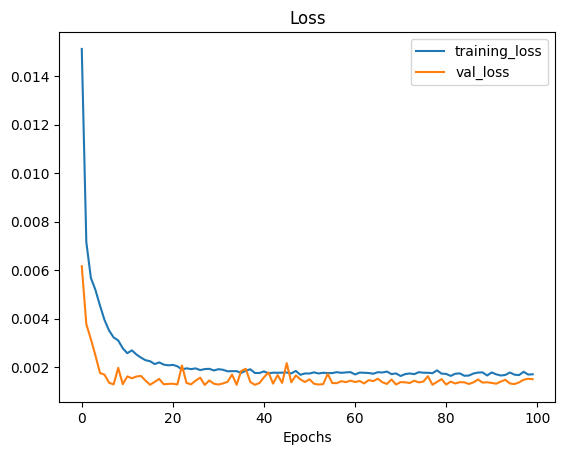

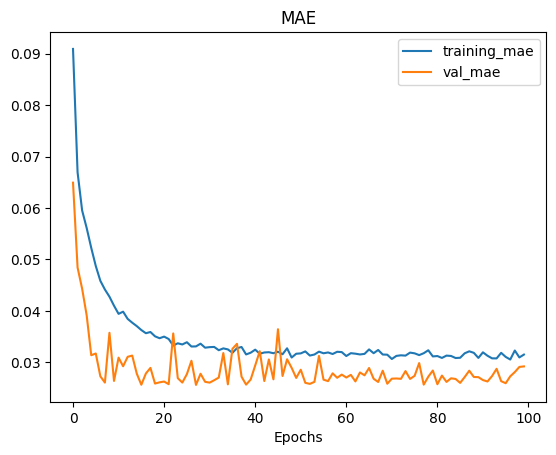

In [30]:
plot_loss_curves(history)

In [32]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 23.0215,
    "longitude": 72.5800,
    "start_date": "2024-06-01",
    "end_date": "2024-12-01",
    "daily": "temperature_2m_mean",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

In [34]:
import pandas as pd

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "tavg": data["daily"]["temperature_2m_mean"]
})

df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.dropna(inplace=True)

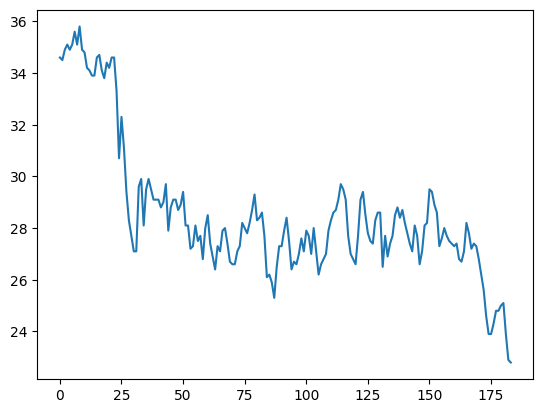

In [35]:

next_6_months_temp = df['tavg'].dropna().values
plt.plot(next_6_months_temp)

In [36]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 23.0215,
    "longitude": 72.5800,
    "start_date": "2024-05-26",
    "end_date": "2024-05-31",
    "daily": "temperature_2m_mean",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

In [37]:
import pandas as pd

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "tavg": data["daily"]["temperature_2m_mean"]
})

df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.dropna(inplace=True)

In [38]:

seed_tavg = df['tavg'].dropna().values.reshape(-1, 1)

seed_scaled = X_scaler.transform(seed_tavg).reshape(-1)
data_for_model = seed_scaled.copy()

In [39]:
output = []
steps = len(next_6_months_temp)

naive_gru_model.eval()
for _ in range(steps):
    inp = torch.tensor(data_for_model.reshape(1, window_size, 1), dtype=torch.float32, device=device)
    with torch.no_grad():
        prediction_scaled = naive_gru_model(inp).cpu().numpy().reshape(1, 1)

    prediction_original = Y_scaler.inverse_transform(prediction_scaled)[0, 0]
    output.append(prediction_original)

    next_value_scaled = prediction_scaled.flatten()[0]
    data_for_model = np.append(data_for_model[1:], next_value_scaled)

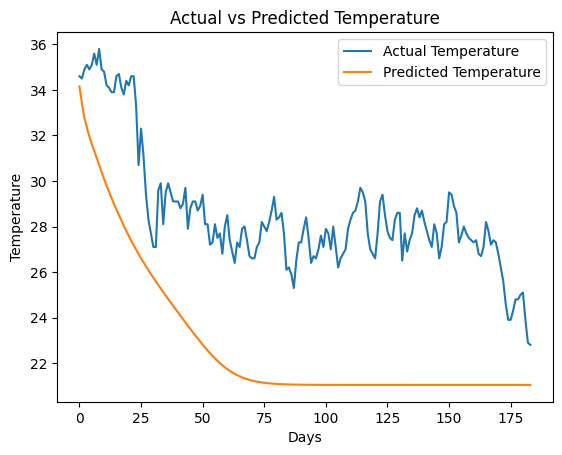

In [40]:
plt.plot(list(next_6_months_temp), label='Actual Temperature')
plt.plot(list(output), label='Predicted Temperature')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Temperature')
plt.title('Actual vs Predicted Temperature')
plt.show()

In [41]:
r2_score(list(next_6_months_temp), output)

-3.8519141528486527

In [43]:
torch.save(naive_gru_model.state_dict(), './naive_gru_model.pth')

# EVALUATION

In [44]:
def model_evaluation(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    medianae = median_absolute_error(y_true, y_pred)
    metrics = {
        'Mean Squared Error': mse,
        'Mean Absolute Error': mae,
        'Median Absolute Error': medianae
    }
    return metrics

In [45]:
def display_metrics(metrics, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(list(metrics.keys()), list(metrics.values()), color='skyblue')
    ax.set_title('Model Evaluation Metrics', fontsize=16, fontweight='bold')
    ax.set_xlabel('Scores', fontsize=12)

    for i, v in enumerate(metrics.values()):
        ax.text(v + 0.01, i, f'{v:.2f}', color='black', va='center', fontsize=10)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

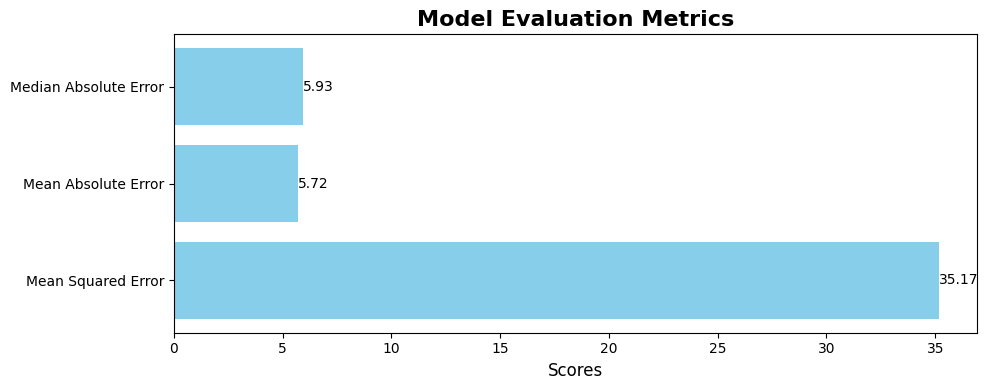

{'Mean Squared Error': 35.16837515995167,
 'Mean Absolute Error': 5.719883506194404,
 'Median Absolute Error': np.float64(5.93408374786377)}

In [46]:
metrics = model_evaluation(list(next_6_months_temp), output)
display_metrics(metrics, 'Matrix_Evaluation_avg.png')
metrics